In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv("/content/creditcard.csv")

print(df.head())

print(df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [ ]:
print(df.info())

print(df.isnull().sum())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21878 entries, 0 to 21877
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    21878 non-null  int64  
 1   V1      21878 non-null  float64
 2   V2      21878 non-null  float64
 3   V3      21878 non-null  float64
 4   V4      21878 non-null  float64
 5   V5      21878 non-null  float64
 6   V6      21878 non-null  float64
 7   V7      21878 non-null  float64
 8   V8      21878 non-null  float64
 9   V9      21878 non-null  float64
 10  V10     21878 non-null  float64
 11  V11     21878 non-null  float64
 12  V12     21878 non-null  float64
 13  V13     21878 non-null  float64
 14  V14     21878 non-null  float64
 15  V15     21878 non-null  float64
 16  V16     21878 non-null  float64
 17  V17     21878 non-null  float64
 18  V18     21878 non-null  float64
 19  V19     21878 non-null  float64
 20  V20     21878 non-null  float64
 21  V21     21878 non-null  float64
 22

In [ ]:
df = df.dropna(subset=['Class'])

In [ ]:
print(df['Class'].value_counts())

Class
0.0    21791
1.0       86
Name: count, dtype: int64


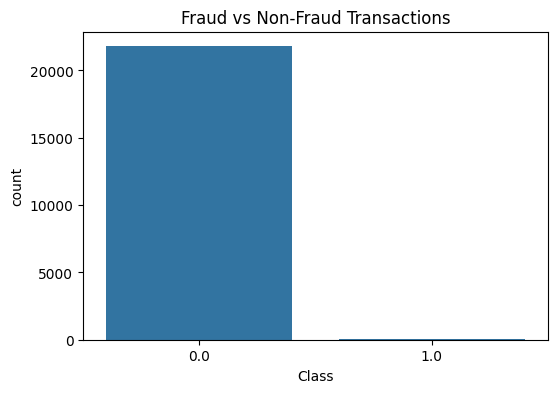

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=df
)

plt.title("Fraud vs Non-Fraud Transactions")

plt.show()

In [ ]:
X = df.drop('Class', axis=1)

y = df['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Logistic Regression Accuracy:")

print(
    accuracy_score(
        y_test,
        lr_pred
    )
)

Logistic Regression Accuracy:
0.9970292504570384


In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(X_test)

In [ ]:
print("Decision Tree Accuracy:")

print(
    accuracy_score(
        y_test,
        dt_pred
    )
)

Decision Tree Accuracy:
0.998400365630713


In [ ]:
print("Logistic Regression Report")

print(
    classification_report(
        y_test,
        lr_pred
    )
)

print("Decision Tree Report")

print(
    classification_report(
        y_test,
        dt_pred
    )
)

Logistic Regression Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      4359
         1.0       0.58      0.82      0.68        17

    accuracy                           1.00      4376
   macro avg       0.79      0.91      0.84      4376
weighted avg       1.00      1.00      1.00      4376

Decision Tree Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      4359
         1.0       0.73      0.94      0.82        17

    accuracy                           1.00      4376
   macro avg       0.86      0.97      0.91      4376
weighted avg       1.00      1.00      1.00      4376



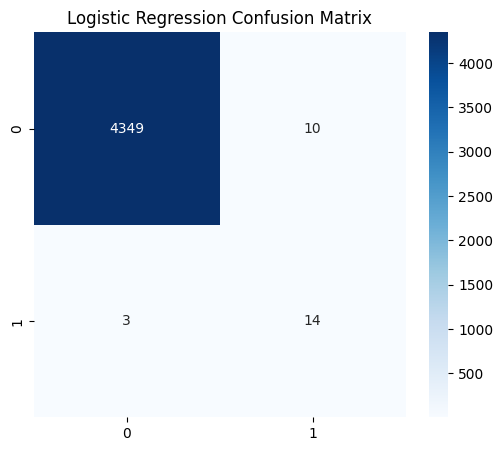

In [ ]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

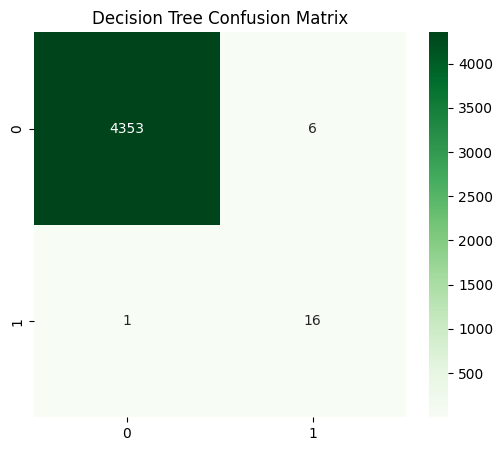

In [ ]:
cm2 = confusion_matrix(
    y_test,
    dt_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

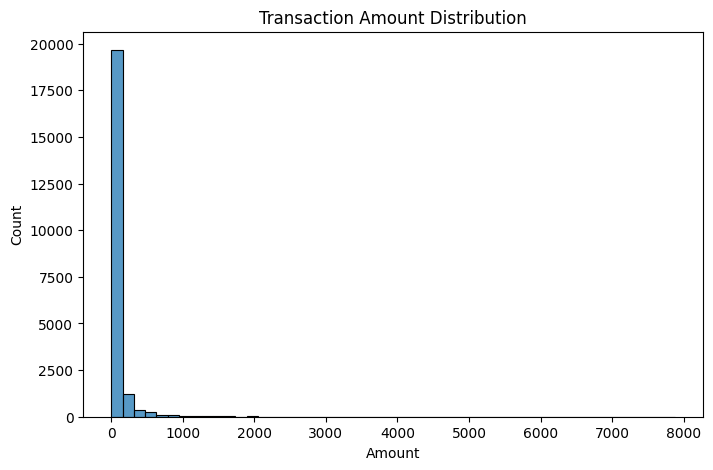

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Amount'],
    bins=50
)

plt.title("Transaction Amount Distribution")

plt.show()

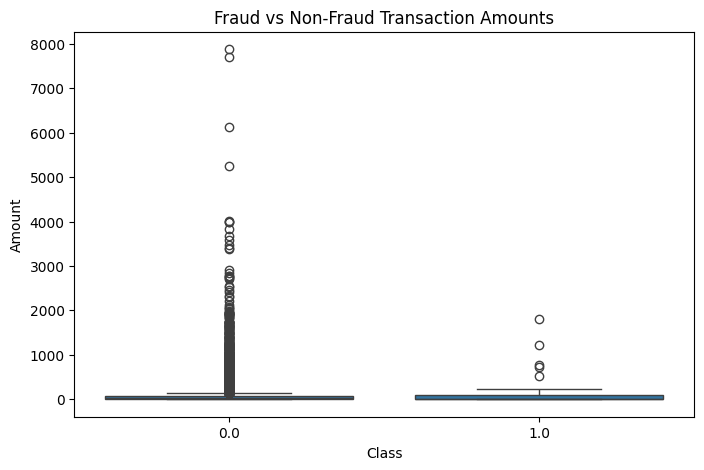

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Class',
    y='Amount',
    data=df
)

plt.title("Fraud vs Non-Fraud Transaction Amounts")

plt.show()

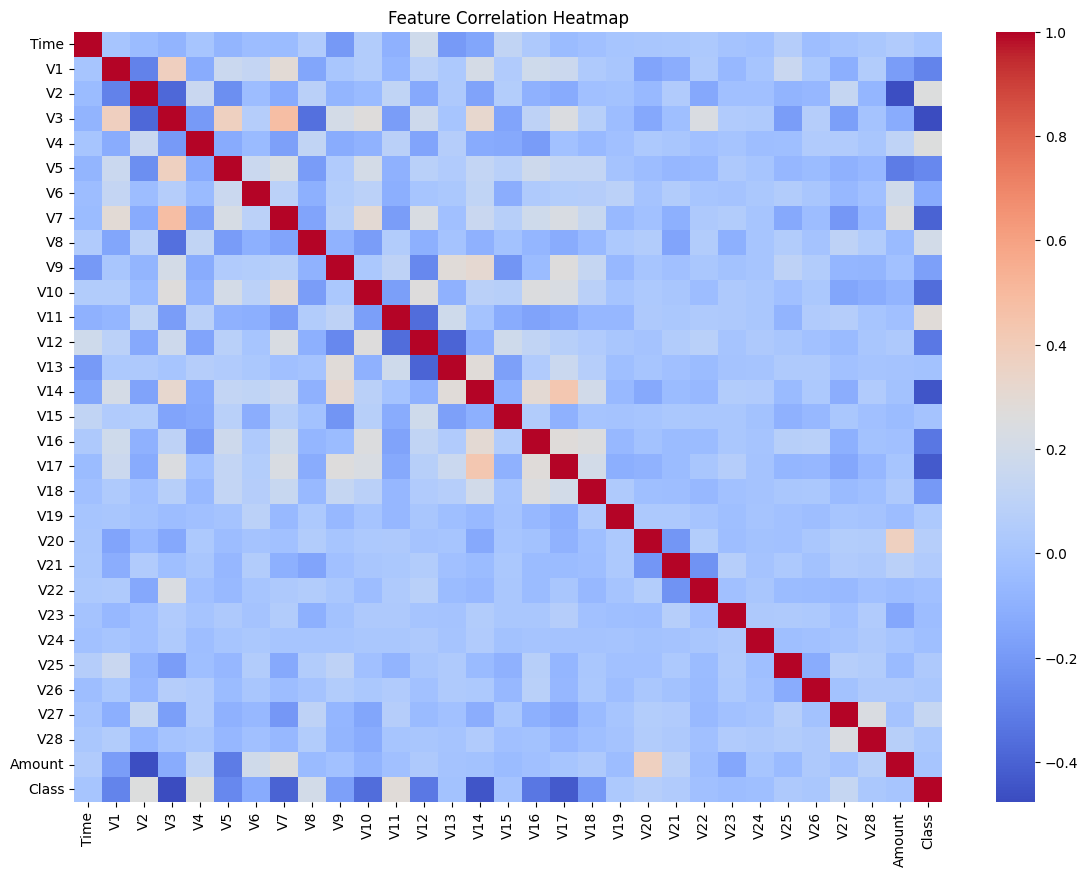

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.997029
1        Decision Tree  0.998400


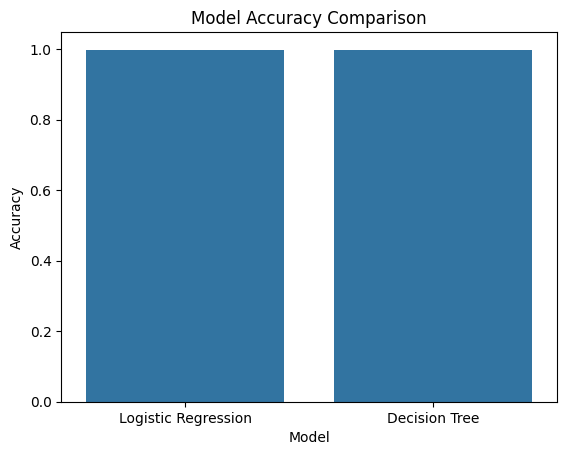

In [ ]:
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Accuracy Comparison")

plt.show()